In [1]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from config import TRAINING_FILE, DATA_DIR
from sklearn.metrics import log_loss, brier_score_loss, roc_auc_score, accuracy_score, roc_curve, auc

In [2]:
df = pd.read_csv(TRAINING_FILE)
    
test_df = df[
    (
        (df["game_id"] >= 22500001) &
        (df["game_id"] < 22600000)
    )
    |
    (
        (df["game_id"] >= 42500001) &
        (df["game_id"] < 42600000)
    )
]

In [3]:
MODEL_FILE = DATA_DIR / "models" / "logistic_regression.joblib"

In [3]:
MODEL_FILE = DATA_DIR / "models" / "xgboost_model.joblib"

In [ ]:
MODEL_FILE = DATA_DIR / "models_old" / "logistic_regression.joblib"

In [ ]:
MODEL_FILE = DATA_DIR / "models_old" / "xgboost_model.joblib"

In [6]:
MODEL_FILE = DATA_DIR / "models_old" / "xgboost_model_b.joblib"

In [7]:
artifact = joblib.load(MODEL_FILE)
model = artifact["model"]
feature_columns = artifact["feature_columns"]

X_test = test_df[feature_columns]
y_test = test_df["home_win"]

pred_proba = model.predict_proba(X_test)[:, 1]

# Convert probabilities to class predictions.
pred_class = (pred_proba >= 0.5).astype(int)

print("Evaluation\n")
print("--------------------------------")
print(f"Log loss:     {log_loss(y_test, pred_proba):.4f}")
print(f"Brier score:  {brier_score_loss(y_test, pred_proba):.4f}")
print(f"ROC AUC:      {roc_auc_score(y_test, pred_proba):.4f}")
print(f"Accuracy:     {accuracy_score(y_test, pred_class):.4f}")

Evaluation

--------------------------------
Log loss:     0.4762
Brier score:  0.1614
ROC AUC:      0.8385
Accuracy:     0.7482


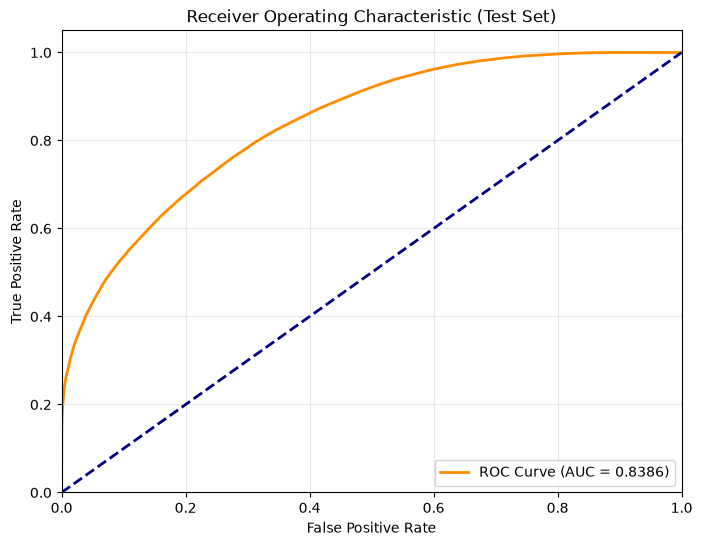

In [5]:
fpr, tpr, thresholds = roc_curve(y_test, pred_proba)
roc_auc = auc(fpr, tpr)

# Plot the ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')

# Plot the diagonal 50/50 chance line
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (Test Set)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()